In [1]:
from tensorflow.keras.datasets import mnist
(x_train , y_train) ,(x_test , y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [2]:
x_train.shape

(60000, 28, 28)

In [3]:
x_test.shape

(10000, 28, 28)

In [4]:
y_train.shape

(60000,)

In [5]:
y_test.shape

(10000,)

In [7]:
x_train = x_train.reshape(60000 ,28 , 28 ,1)
x_test = x_test.reshape(10000 ,28 , 28 ,1)

In [8]:
from tensorflow.keras import utils

In [9]:
y_train= utils.to_categorical(y_train , 10) # change to categorcal data
y_test= utils.to_categorical(y_test , 10)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

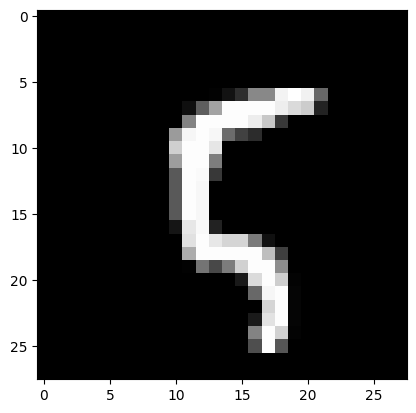

In [11]:
plt.imshow(x_train[100], cmap='gray')
plt.show()

In [12]:
arr = y_train[100]
print(arr)

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [13]:
label = np.argmax(arr)
label

5

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout , Flatten , Conv2D

In [16]:
model = Sequential()

In [17]:
input_layer = Dense(32 , input_shape = (28 , 28,1))

In [18]:
model.add(input_layer)

In [19]:
conv_layer1 = Conv2D(32, kernel_size = (3 , 3) , activation = 'relu')

In [20]:
model.add(conv_layer1)

In [21]:
conv_layer2 = Conv2D(64 , (3,3) , activation = 'relu')

In [22]:
model.add(conv_layer2)

In [24]:
from tensorflow.keras.layers import MaxPooling2D
pool_layer = MaxPooling2D(pool_size = (2,2))

In [25]:
model.add(pool_layer)

In [26]:
drop_layer = Dropout(0.5)

In [27]:
model.add(drop_layer)

In [28]:
flat_layer = Flatten()
model.add(flat_layer)

In [29]:
output_layer = Dense(10 , activation= 'softmax')

In [30]:
model.add(output_layer)

In [31]:
model.compile(loss = 'categorical_crossentropy' ,optimizer = 'adam' , metrics = ['accuracy'])

In [32]:
history = model.fit(x_train, y_train ,
                    batch_size = 32 , # no. of sample
                    epochs = 10 ,
                    verbose = 1,
                    validation_data = (x_test , y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 187s 99ms/step - accuracy: 0.9364 - loss: 0.2953 - val_accuracy: 0.9698 - val_loss: 0.0976
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 196s 104ms/step - accuracy: 0.9681 - loss: 0.1099 - val_accuracy: 0.9841 - val_loss: 0.0572
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 194s 103ms/step - accuracy: 0.9736 - loss: 0.0886 - val_accuracy: 0.9849 - val_loss: 0.0474
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 189s 101ms/step - accuracy: 0.9795 - loss: 0.0662 - val_accuracy: 0.9858 - val_loss: 0.0429
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 191s 102ms/step - accuracy: 0.9832 - loss: 0.0537 - val_accuracy: 0.9864 - val_loss: 0.0423
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 194s 104ms/step - accuracy: 0.9850 - loss: 0.0457 - val_accuracy: 0.9862 - val_loss: 0.0443
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 203s 108ms/step - accuracy: 0.9862 - loss: 0.0430 - val_accuracy: 0.9872 - val_loss: 0.0407
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 218s 116ms/step - acc

In [33]:
val_loss , val_acc = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9887 - loss: 0.0379


In [34]:
print(val_loss , val_acc)

0.037877317517995834 0.9886999726295471


In [35]:
arr = model.predict([x_train[100].reshape(1,28,28,1)])
print(arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
[[2.7471256e-09 1.4497616e-08 5.3312519e-08 2.1749452e-06 1.0695541e-08
  9.9850237e-01 8.0156734e-04 1.2536976e-08 6.8748055e-04 6.4553997e-06]]


In [36]:
label = np.argmax(arr)
print(label)

5


In [37]:
from PIL import Image ,ImageOps

In [39]:
img = Image.open("two-small.png").convert('L')

In [40]:
img_inverted = ImageOps.invert(img)

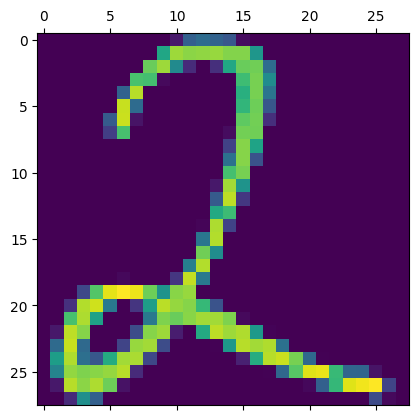

In [41]:
plt.matshow(img_inverted)

In [42]:
arr = np.array(img_inverted)

In [43]:
arr = model.predict([arr.reshape(1,28,28,1)])
print(arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
[[1.7727967e-07 3.1649444e-02 9.6793324e-01 8.6279242e-06 1.5988888e-05
  6.1732010e-08 3.8554499e-04 3.2296757e-06 4.8988835e-07 3.2860655e-06]]


In [44]:
label = np.argmax(arr)

In [45]:
print(label)

2


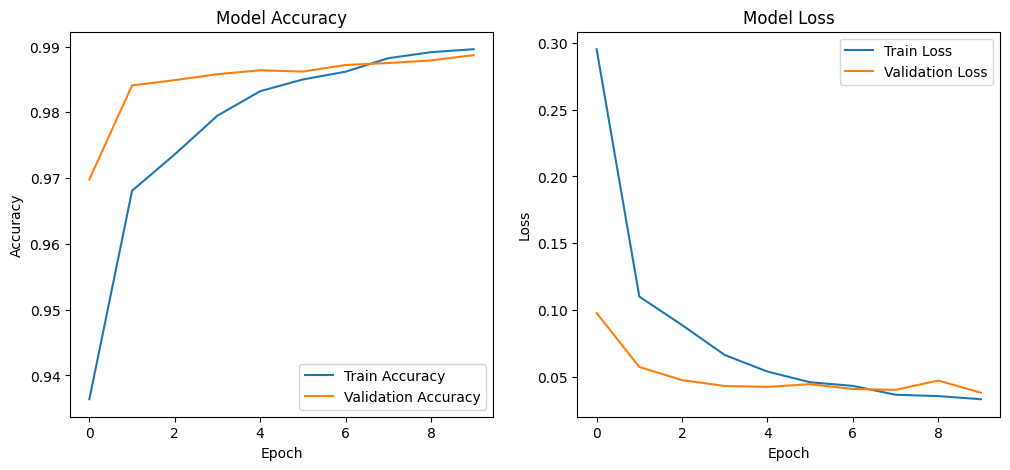

In [46]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [48]:
model.save("mnist_model.keras")